Epoch [100/500], Loss: 0.780019
Epoch [200/500], Loss: 0.267866
Epoch [300/500], Loss: 0.201010
Epoch [400/500], Loss: 0.137892
Epoch [500/500], Loss: 0.089954


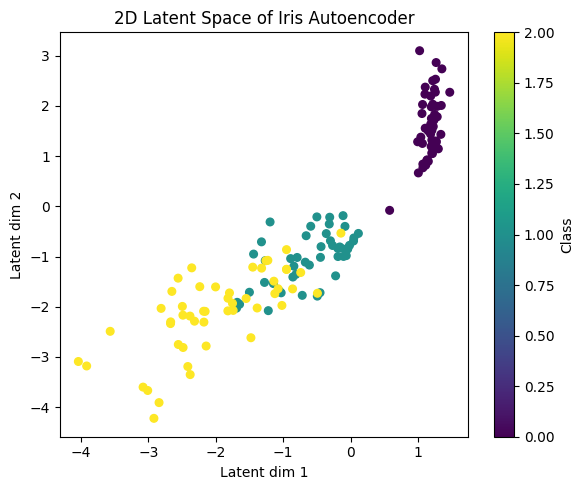

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Load and preprocess data
# ---------------------------
iris = load_iris()
X = iris.data
y = iris.target

X = StandardScaler().fit_transform(X)
X = torch.tensor(X, dtype=torch.float32)

# ---------------------------
# Autoencoder definition
# ---------------------------
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 2)   # 2D latent space
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

# ---------------------------
# Training setup
# ---------------------------
model = AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ---------------------------
# Training loop
# ---------------------------
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    recon = model(X)
    loss = criterion(recon, X)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

# ---------------------------
# Extract latent space
# ---------------------------
with torch.no_grad():
    Z = model.encoder(X).numpy()

# ---------------------------
# Visualization
# ---------------------------
plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y, cmap="viridis", s=30)
plt.xlabel("Latent dim 1")
plt.ylabel("Latent dim 2")
plt.title("2D Latent Space of Iris Autoencoder")
plt.colorbar(scatter, label="Class")
plt.tight_layout()
plt.show()
